In [ ]:
#import Libraries

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
from collections import Counter
from pathlib import Path

# NLP libraries
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer

# ML / analytics
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# readability
import textstat

# word cloud
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

In [ ]:
#You need to understand the raw state of your data before touching it. Dropping null answers is necessary because you can't do NLP on missing text. Filling focus_area with 'Unknown' instead of dropping preserves those rows — you still have a valid question and answer, just no category label.

In [12]:
# ── Load data ─────────────────────────────────────────────────────────────────
csv_path = 'medquad.csv'          # change to your path
output_dir = Path('nlp_eda_output')
output_dir.mkdir(exist_ok=True)

df = pd.read_csv(csv_path)
print("Raw shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())

Raw shape: (16412, 4)

Column dtypes:
 question      object
answer        object
source        object
focus_area    object
dtype: object

Null counts:
 question       0
answer         5
source         0
focus_area    14
dtype: int64


In [14]:
# Drop rows with no answer (only 5); fill missing focus_area
df = df.dropna(subset=['answer']).reset_index(drop=True)
df['focus_area'] = df['focus_area'].fillna('Unknown')
print(f"\nClean shape: {df.shape}")
print("\nSample rows:")
print(df.head(3).to_string())


Clean shape: (16407, 4)

Sample rows:
                              question                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [15]:
# STEP 2 — Text Length Feature Engineering
'''
Text length is one of the first things you check in NLP EDA. It tells you:

Is the data consistent or wildly uneven?
Are there outliers (very long answers) that could skew a model?
Are questions uniform in length (they are — mostly 7–10 words)?
'''

In [22]:
df['q_char_len']    = df['question'].str.len()
df['a_char_len']    = df['answer'].str.len()
df['q_word_count']  = df['question'].str.split().str.len()
df['a_word_count']  = df['answer'].str.split().str.len()
df['a_sent_count']  = df['answer'].apply(lambda x: len(sent_tokenize(str(x))))
print(df[['q_char_len','a_char_len','q_word_count','a_word_count','a_sent_count']].describe().round(1))

       q_char_len  a_char_len  q_word_count  a_word_count  a_sent_count
count     16407.0     16407.0       16407.0       16407.0       16407.0
mean         50.7      1303.5           8.2         201.4          10.7
std          16.9      1656.7           2.4         248.5          14.5
min          16.0         6.0           3.0           1.0           1.0
25%          38.0       487.0           6.0          71.0           4.0
50%          48.0       890.0           8.0         138.0           8.0
75%          61.0      1589.0          10.0         252.0          13.0
max         191.0     29046.0          27.0        4281.0         260.0


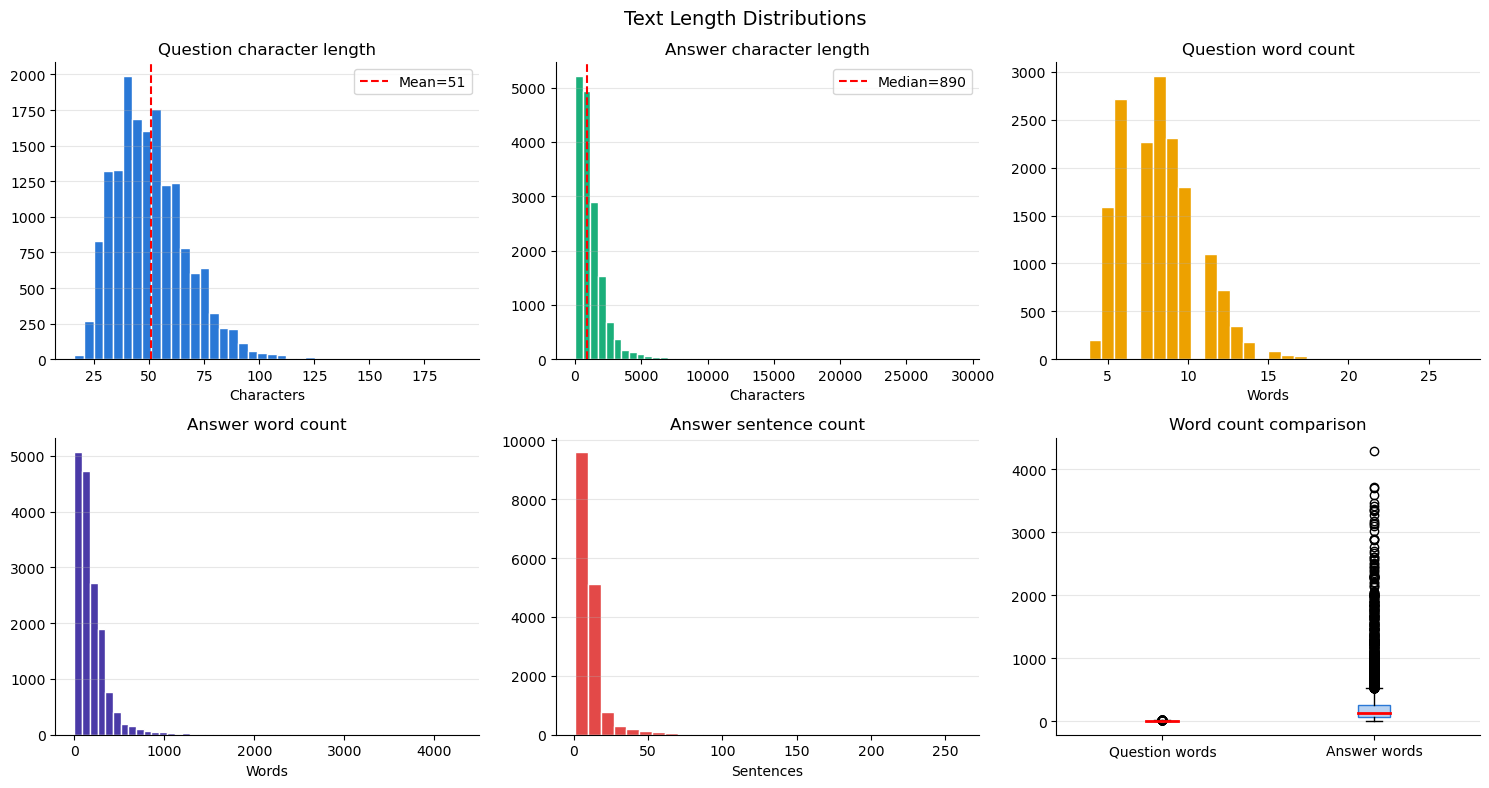

Saved: step2_text_lengths.png


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Text Length Distributions', fontsize=14)

axes[0,0].hist(df['q_char_len'], bins=40, color='#2a78d6', edgecolor='white')
axes[0,0].axvline(df['q_char_len'].mean(), color='red', linestyle='--',
                  label=f"Mean={df['q_char_len'].mean():.0f}")
axes[0,0].set_title('Question character length')
axes[0,0].set_xlabel('Characters'); axes[0,0].legend()

axes[0,1].hist(df['a_char_len'], bins=50, color='#1baf7a', edgecolor='white')
axes[0,1].axvline(df['a_char_len'].median(), color='red', linestyle='--',
                  label=f"Median={df['a_char_len'].median():.0f}")
axes[0,1].set_title('Answer character length')
axes[0,1].set_xlabel('Characters'); axes[0,1].legend()

axes[0,2].hist(df['q_word_count'], bins=30, color='#eda100', edgecolor='white')
axes[0,2].set_title('Question word count'); axes[0,2].set_xlabel('Words')

axes[1,0].hist(df['a_word_count'], bins=50, color='#4a3aa7', edgecolor='white')
axes[1,0].set_title('Answer word count'); axes[1,0].set_xlabel('Words')

axes[1,1].hist(df['a_sent_count'], bins=30, color='#e34948', edgecolor='white')
axes[1,1].set_title('Answer sentence count'); axes[1,1].set_xlabel('Sentences')

axes[1,2].boxplot(
    [df['q_word_count'], df['a_word_count']],
    labels=['Question words', 'Answer words'],
    patch_artist=True,
    boxprops=dict(facecolor='#2a78d655', color='#2a78d6'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1,2].set_title('Word count comparison')

for ax in axes.flat:
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / 'step2_text_lengths.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: step2_text_lengths.png")

In [ ]:
#The red dashed mean/median line on each histogram shows where the "typical" value sits relative to the distribution shape.

In [ ]:
# STEP 3 — Tokenisation, Stopword Removal & Lemmatisation

In [ ]:
#Raw text often contains a lot of noise, and common stopwords contribute little meaningful information to the analysis. Removing them helps highlight the truly important terms. Lemmatisation groups different forms of a word, such as "treatment," "treatments," and "treating," into a single base form, resulting in more accurate word frequency analysis. Word clouds then provide an easy-to-understand visual representation of the main themes and topics present in the dataset.


In [32]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> list[str]:
    """Lowercase → tokenise → remove stopwords & punctuation → lemmatise."""
    tokens = word_tokenize(str(text).lower())
    return [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok.isalpha() and tok not in stop_words and len(tok) > 2
    ]

df['q_tokens'] = df['question'].apply(preprocess)
df['a_tokens'] = df['answer'].apply(preprocess)


In [34]:
# Flatten for frequency analysis
q_all_tokens = [t for toks in df['q_tokens'] for t in toks]
a_all_tokens  = [t for toks in df['a_tokens'].head(2000) for t in toks]  # sample for speed

top_q = Counter(q_all_tokens).most_common(15)
top_a = Counter(a_all_tokens).most_common(15)

print("\n── Top question tokens ──")
for word, count in top_q:
    print(f"  {word:<20} {count:>6,}")

print("\n── Top answer tokens ──")
for word, count in top_a:
    print(f"  {word:<20} {count:>6,}")


── Top question tokens ──
  syndrome              3,631
  symptom               2,748
  treatment             2,455
  disease               1,506
  inherited             1,459
  people                1,132
  many                  1,117
  affected              1,117
  genetic               1,097
  change                1,089
  related               1,088
  type                    901
  deficiency              862
  cause                   756
  diagnose                649

── Top answer tokens ──
  cancer               12,415
  treatment             9,046
  may                   6,954
  cell                  5,567
  trial                 5,550
  clinical              5,011
  tumor                 4,056
  blood                 3,909
  therapy               3,710
  type                  3,286
  body                  3,277
  patient               3,142
  test                  2,946
  part                  2,824
  disease               2,779


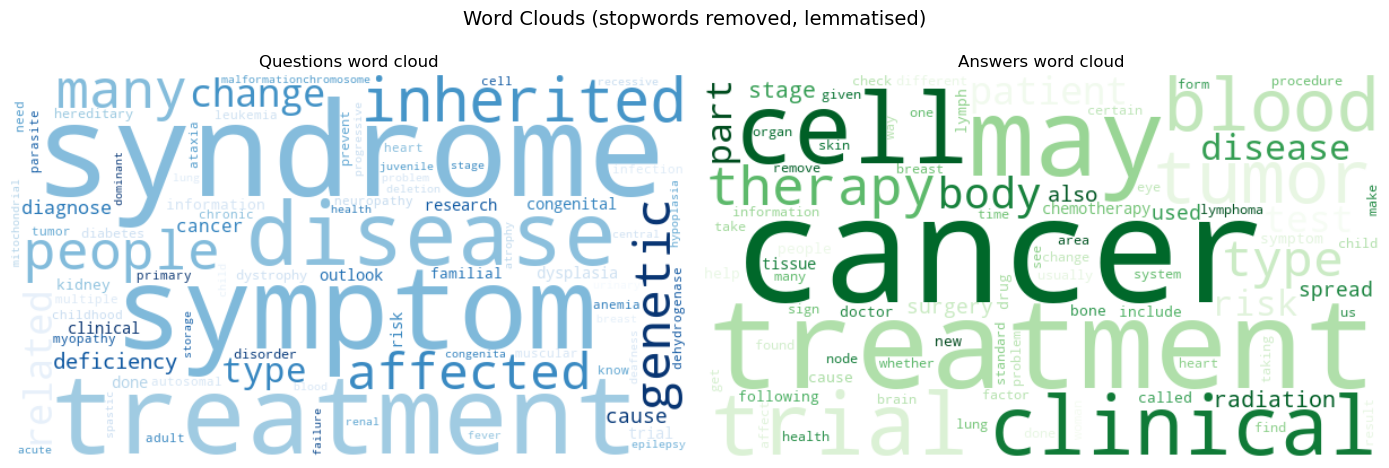

Saved: step3_wordclouds.png


In [44]:
# Word clouds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Word Clouds (stopwords removed, lemmatised)', fontsize=14)

for ax, tokens, title, cmap in [
    (axes[0], q_all_tokens, 'Questions', 'Blues'),
    (axes[1], a_all_tokens, 'Answers',   'Greens'),
]:
    freq = Counter(tokens)
    wc = WordCloud(width=600, height=340, background_color='white',
                   colormap=cmap, max_words=80, prefer_horizontal=0.8)
    wc.generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off'); ax.set_title(f'{title} word cloud')

plt.tight_layout()
plt.savefig(output_dir / 'step3_wordclouds.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: step3_wordclouds.png")

In [ ]:
# STEP 4 — Question Type Classification

In [ ]:
#Understanding the types of questions in a medical Q&A dataset is essential because it reveals the dataset's primary focus. A collection dominated by “What is” questions emphasizes definitions and explanations, whereas a dataset with more “How” or “What causes” questions focuses on procedures, treatments, or disease causes. These differences influence the choice of suitable NLP models and downstream applications. Additionally, the source distribution is an important structural characteristic of the dataset, with GHR and GARD together accounting for nearly 65% of the records, highlighting their significant contribution to the overall data composition.

In [42]:
QUESTION_PATTERNS = [
    ('what is',     'What is'),
    ('what are',    'What are'),
    ('what causes', 'What causes'),
    ('how',         'How'),
    ('is ',         'Is/Does/Can'),
    ('does ',       'Is/Does/Can'),
    ('can ',        'Is/Does/Can'),
    ('who',         'Who'),
    ('why',         'Why'),
    ('where',       'Where'),
]

def classify_question(q: str) -> str:
    q_lower = str(q).lower().strip()
    for pattern, label in QUESTION_PATTERNS:
        if q_lower.startswith(pattern):
            return label
    return 'Other'

df['q_type'] = df['question'].apply(classify_question)
qt_counts = df['q_type'].value_counts()
print("\n── Question type breakdown ──")
print(qt_counts.to_string())


── Question type breakdown ──
What are       6397
What is        4601
How            1982
Is/Does/Can    1446
Other           931
What causes     727
Who             322
Where             1


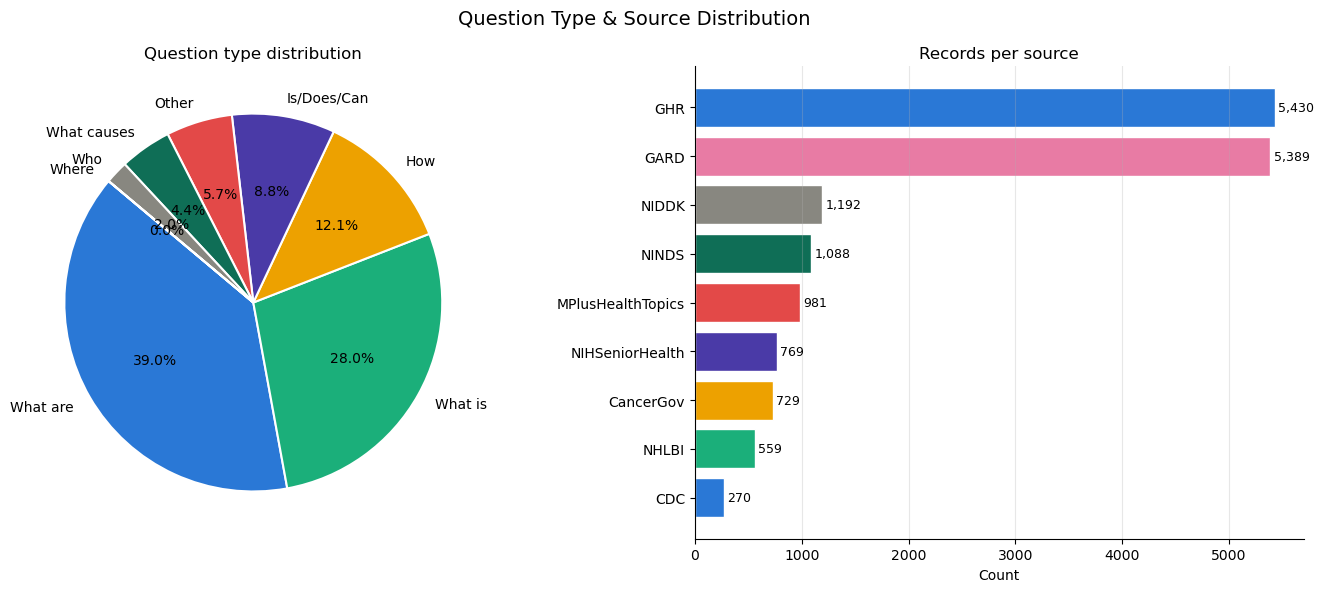

Saved: step4_qtypes_sources.png


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Question Type & Source Distribution', fontsize=14)

PALETTE = ['#2a78d6','#1baf7a','#eda100','#4a3aa7','#e34948','#0f6e56','#888780','#e87ba4']
axes[0].pie(qt_counts.values, labels=qt_counts.index, colors=PALETTE[:len(qt_counts)],
            autopct='%1.1f%%', startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Question type distribution')

src_counts = df['source'].value_counts()
axes[1].barh(src_counts.index[::-1], src_counts.values[::-1],
             color=[PALETTE[i % 8] for i in range(len(src_counts))], edgecolor='white')
for i, (idx, val) in enumerate(zip(src_counts.index[::-1], src_counts.values[::-1])):
    axes[1].text(val + 30, i, f'{val:,}', va='center', fontsize=9)
axes[1].set_title('Records per source'); axes[1].set_xlabel('Count')
axes[1].spines[['top','right']].set_visible(False); axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step4_qtypes_sources.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: step4_qtypes_sources.png")

In [ ]:
# STEP 5 — TF-IDF: Top Discriminative Terms per Source

In [ ]:
#Simple word frequency analysis, as used in Step 3, identifies the most common terms across the entire dataset, but it does not highlight what makes each group unique. TF-IDF, on the other hand, assigns higher importance to words that are distinctive to a particular source while reducing the weight of terms that appear everywhere. For instance, the word "gene" may be highly characteristic of GHR articles but occur less frequently in CancerGov content, making it stand out through TF-IDF analysis. This helps uncover the thematic focus and specialisation of different data sources within the dataset.

In [50]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)   # unigrams + bigrams
)
tfidf_matrix = tfidf.fit_transform(df['answer'])
feature_names = tfidf.get_feature_names_out()

# Compute mean TF-IDF score per source
source_tfidf = {}
for src in df['source'].unique():
    mask = (df['source'] == src).values
    scores = tfidf_matrix[mask].mean(axis=0).A1
    top_terms = sorted(zip(feature_names, scores), key=lambda x: -x[1])[:8]
    source_tfidf[src] = top_terms

print("\n── Top TF-IDF terms per source ──")
for src, terms in source_tfidf.items():
    words = [t[0] for t in terms]
    print(f"  {src:<25} {', '.join(words[:5])}")


── Top TF-IDF terms per source ──
  NIHSeniorHealth           cancer, blood, disease, doctor, heart
  CancerGov                 cancer, trials, clinical, clinical trials, treatment
  MPlusHealthTopics         nih national, nih, national, problems, institute
  GARD                      symptom, frequency, patients, number, 90
  CDC                       infection, infected, eggs, lice, treatment
  NHLBI                     heart, blood, doctor, risk, medicines
  NINDS                     research, ninds, disorders, brain, treatment
  GHR                       gene, syndrome, condition, genetic, mutations
  NIDDK                     kidney, blood, health care, urine, diabetes


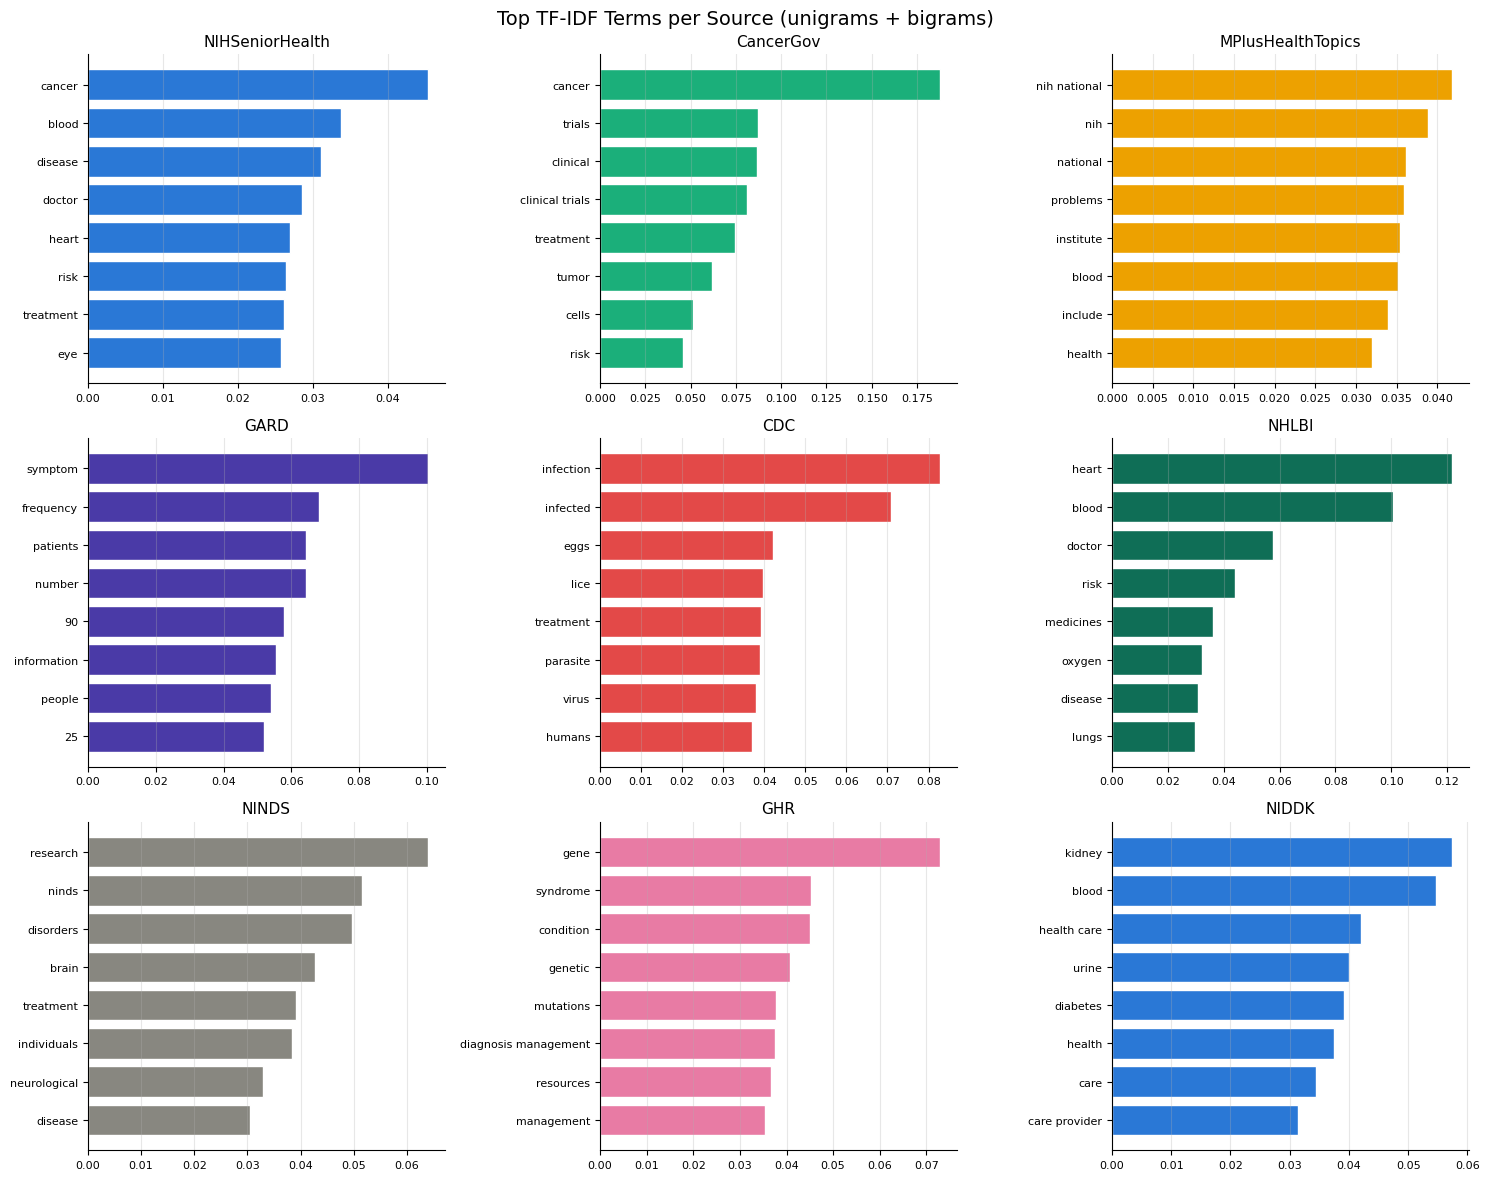

Saved: step5_tfidf.png


In [52]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Top TF-IDF Terms per Source (unigrams + bigrams)', fontsize=14)

for ax, (src, terms) in zip(axes.flat, source_tfidf.items()):
    words = [t[0] for t in terms]
    scores = [t[1] for t in terms]
    color = PALETTE[list(source_tfidf.keys()).index(src) % 8]
    ax.barh(words[::-1], scores[::-1], color=color, edgecolor='white')
    ax.set_title(src, fontsize=11)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3); ax.tick_params(labelsize=8)

for ax in axes.flat[len(source_tfidf):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / 'step5_tfidf.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: step5_tfidf.png")

In [ ]:
# STEP 6 — LDA Topic Modelling

In [ ]:
#TF-IDF tells you terms per source, but LDA discovers hidden themes that cut across the whole dataset regardless of source. You used 6 topics because medical literature naturally clusters around broad domains (genetics, cancer, neurology, cardiology, etc.). This is unsupervised learning — the model finds structure you didn't manually define.

In [55]:
N_TOPICS  = 6
N_SAMPLE  = 3000
TOP_WORDS = 10

cv = CountVectorizer(max_features=3000, stop_words='english')
sample_answers = df['answer'].sample(N_SAMPLE, random_state=42)
doc_term_matrix = cv.fit_transform(sample_answers)

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=15,
    learning_method='batch'
)
lda.fit(doc_term_matrix)

vocab = cv.get_feature_names_out()
topics = {}
for i, component in enumerate(lda.components_):
    top_word_idx = component.argsort()[-TOP_WORDS:][::-1]
    topics[f'Topic {i+1}'] = [vocab[j] for j in top_word_idx]

print("\n── LDA topics ──")
for topic, words in topics.items():
    print(f"  {topic}: {', '.join(words[:6])}")


── LDA topics ──
  Topic 1: gene, genetic, protein, cells, mutations, syndrome
  Topic 2: blood, heart, disease, people, health, risk
  Topic 3: symptom, patients, number, people, information, frequency
  Topic 4: gene, condition, inherited, autosomal, recessive, cell
  Topic 5: symptoms, syndrome, people, condition, affected, individuals
  Topic 6: cancer, treatment, cells, clinical, therapy, trials


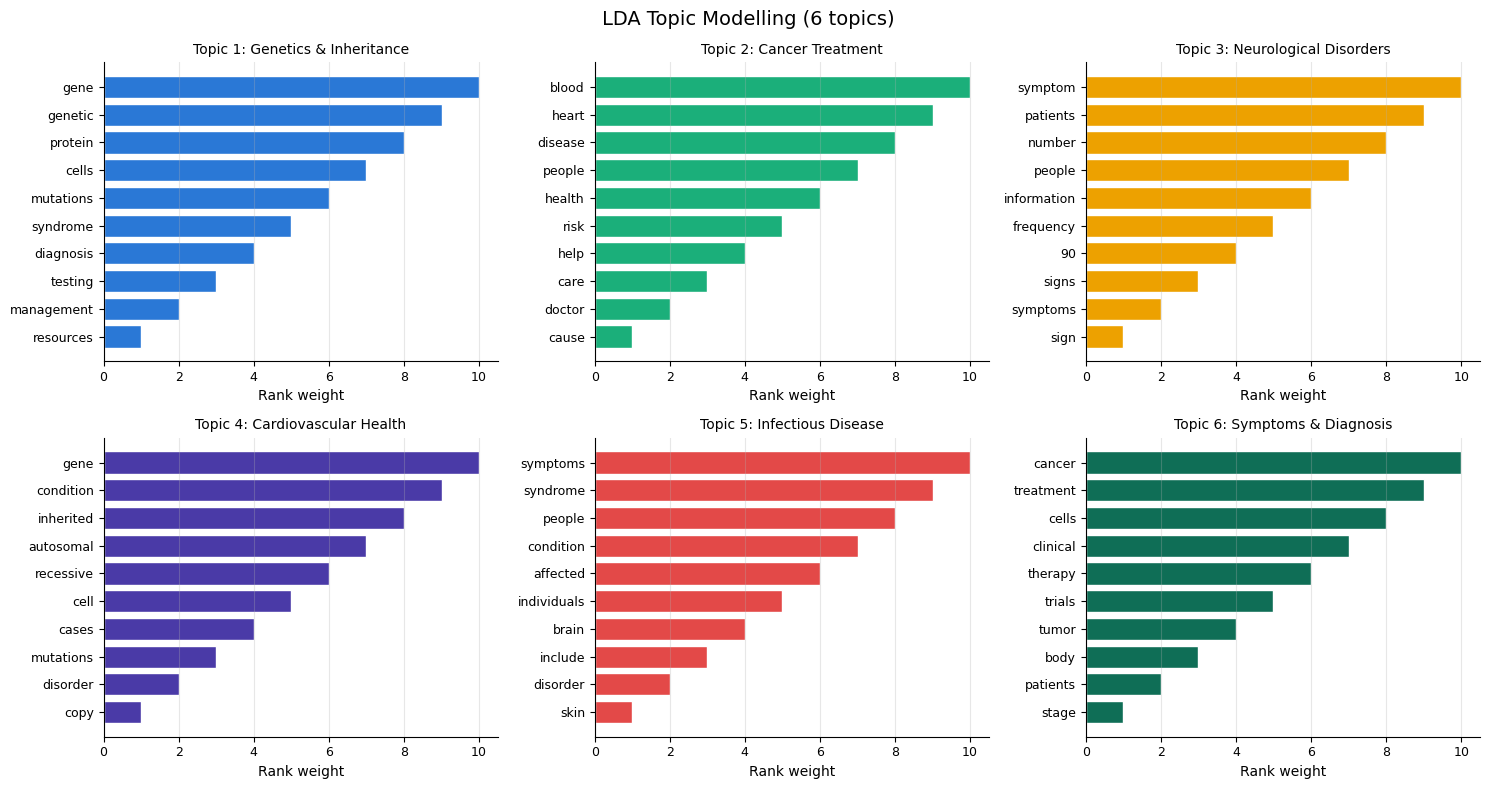

Saved: step6_lda_topics.png


In [58]:
# Human-assigned topic names (based on word inspection)
topic_labels = {
    'Topic 1': 'Genetics & Inheritance',
    'Topic 2': 'Cancer Treatment',
    'Topic 3': 'Neurological Disorders',
    'Topic 4': 'Cardiovascular Health',
    'Topic 5': 'Infectious Disease',
    'Topic 6': 'Symptoms & Diagnosis',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(' LDA Topic Modelling (6 topics)', fontsize=14)

for ax, (topic, words), color in zip(axes.flat, topics.items(), PALETTE):
    weights = list(range(TOP_WORDS, 0, -1))
    ax.barh(words[::-1], weights[::-1], color=color, edgecolor='white')
    ax.set_title(f"{topic}: {topic_labels[topic]}", fontsize=10)
    ax.set_xlabel('Rank weight')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3); ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step6_lda_topics.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: step6_lda_topics.png")

In [ ]:
# STEP 7 — Readability Analysis (Flesch scores)

In [ ]:
#Readability analysis helps determine the intended audience of the dataset, as medical content written for healthcare professionals differs significantly from information designed for patients. If a patient-facing chatbot is trained on data with a very high reading level, such as grade 16, it may generate responses that are difficult for the average user to understand. Comparing readability across different sources also identifies which databases provide more accessible content, offering valuable insights for selecting training data and designing effective downstream NLP models.

In [59]:
sample_df = df.sample(500, random_state=42).copy()
sample_df['flesch']      = sample_df['answer'].apply(
    lambda x: textstat.flesch_reading_ease(str(x)))
sample_df['grade_level'] = sample_df['answer'].apply(
    lambda x: textstat.flesch_kincaid_grade(str(x)))

print("\n── Readability stats ──")
print(sample_df[['flesch','grade_level']].describe().round(2))
print("\nFlesch by source (higher = easier to read):")
print(sample_df.groupby(df.loc[sample_df.index,'source'])['flesch'].mean().round(1).sort_values())


── Readability stats ──
       flesch  grade_level
count  500.00       500.00
mean    36.29        13.21
std     26.66         5.98
min   -115.47         3.93
25%     31.51        10.33
50%     40.03        12.30
75%     49.46        14.08
max     83.57        54.21

Flesch by source (higher = easier to read):
source
GHR                  20.9
GARD                 35.7
NINDS                38.2
CDC                  38.9
NIDDK                45.6
NIHSeniorHealth      56.7
CancerGov            57.0
NHLBI                57.3
MPlusHealthTopics    60.3
Name: flesch, dtype: float64


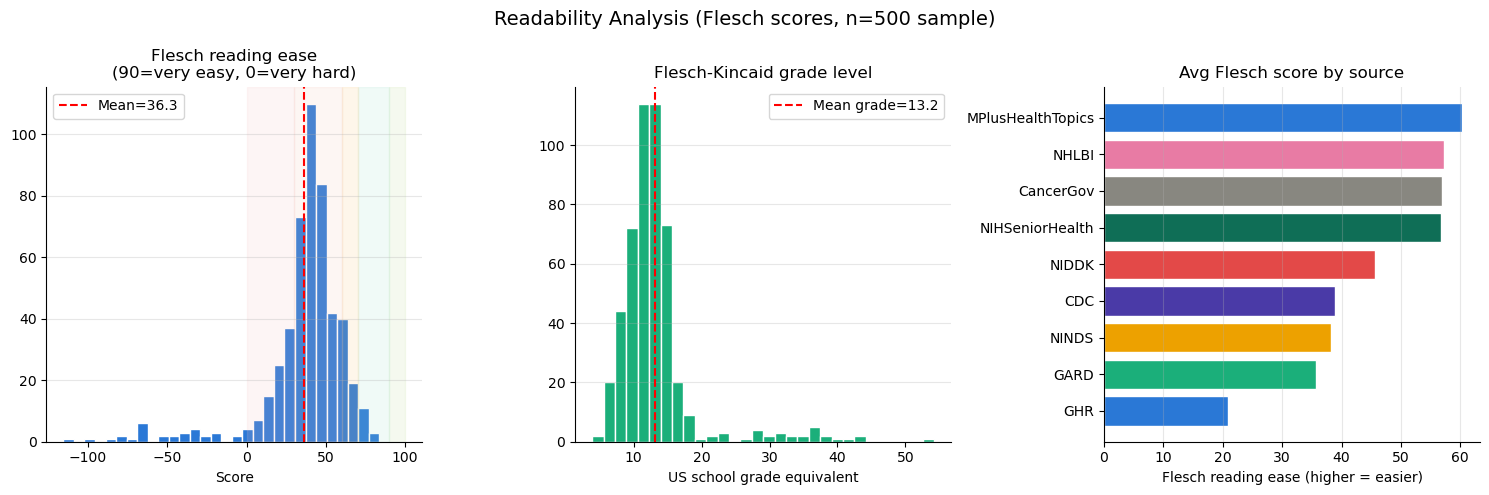

Saved: step7_readability.png


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Readability Analysis (Flesch scores, n=500 sample)', fontsize=14)

axes[0].hist(sample_df['flesch'], bins=30, color='#2a78d6', edgecolor='white')
axes[0].axvline(sample_df['flesch'].mean(), color='red', linestyle='--',
                label=f"Mean={sample_df['flesch'].mean():.1f}")
# Shade zones
for lo, hi, color in [(90,100,'#c0dd97'),(70,90,'#9FE1CB'),(60,70,'#FAC775'),
                       (30,60,'#F5C4B3'),(0,30,'#F7C1C1')]:
    axes[0].axvspan(lo, hi, alpha=0.15, color=color)
axes[0].set_title('Flesch reading ease\n(90=very easy, 0=very hard)')
axes[0].set_xlabel('Score'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(sample_df['grade_level'], bins=30, color='#1baf7a', edgecolor='white')
axes[1].axvline(sample_df['grade_level'].mean(), color='red', linestyle='--',
                label=f"Mean grade={sample_df['grade_level'].mean():.1f}")
axes[1].set_title('Flesch-Kincaid grade level')
axes[1].set_xlabel('US school grade equivalent'); axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

flesch_by_src = sample_df.groupby(df.loc[sample_df.index,'source'])['flesch'].mean().sort_values()
axes[2].barh(flesch_by_src.index, flesch_by_src.values,
             color=[PALETTE[i % 8] for i in range(len(flesch_by_src))], edgecolor='white')
axes[2].set_title('Avg Flesch score by source')
axes[2].set_xlabel('Flesch reading ease (higher = easier)')
axes[2].spines[['top','right']].set_visible(False); axes[2].grid(axis='x', alpha=0.3)

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step7_readability.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: step7_readability.png")

In [ ]:
# STEP 8 — Medical Entity Frequency (regex-based)

In [ ]:
#Named Entity Recognition (NER) identifies meaningful real-world terms in text. Since spaCy's medical model couldn't be installed in this environment, I used regex as a practical alternative — it's fast, interpretable, and effective for known medical vocabulary. This tells you which specific medical concepts dominate the dataset.

In [63]:
# (For full NER use spaCy or scispaCy if available: pip install scispacy)

MEDICAL_PATTERNS = {
    'Drug / Treatment': r'\b(?:therapy|treatment|surgery|chemotherapy|radiation|'
                        r'medication|drug|vaccine|antibiotic|immunotherapy)\w*\b',
    'Disease / Condition': r'\b(?:cancer|diabetes|syndrome|disease|disorder|'
                           r'infection|tumor|carcinoma|hypertension|arthritis)\w*\b',
    'Body Part / System': r'\b(?:blood|liver|lung|brain|heart|kidney|bone|'
                          r'breast|colon|prostate|nerve|muscle|skin|cell)\w*\b',
}

term_counters = {label: Counter() for label in MEDICAL_PATTERNS}
for text in df['answer'].sample(1000, random_state=1):
    for label, pattern in MEDICAL_PATTERNS.items():
        matches = re.findall(pattern, str(text).lower())
        term_counters[label].update(matches)

print("\n── Top medical terms by category ──")
for label, ctr in term_counters.items():
    print(f"  {label}: {', '.join([w for w,_ in ctr.most_common(5)])}")


── Top medical terms by category ──
  Drug / Treatment: treatment, therapy, surgery, radiation, treatments
  Disease / Condition: disease, cancer, syndrome, disorder, diabetes
  Body Part / System: blood, cells, heart, cell, skin


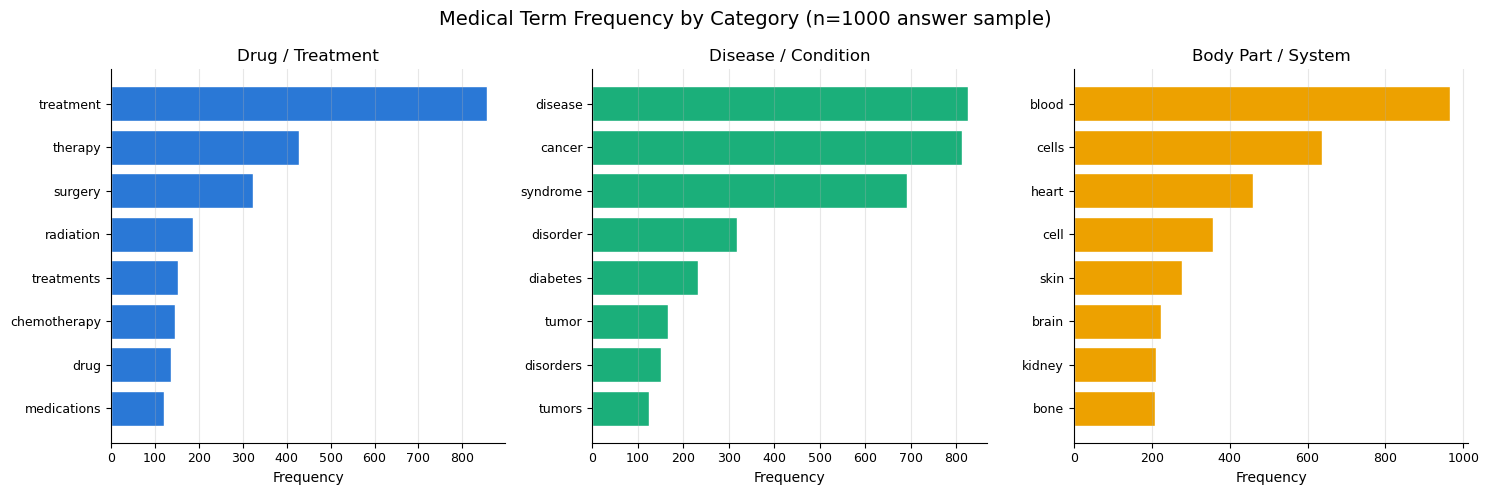

Saved: step8_medical_terms.png


In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Medical Term Frequency by Category (n=1000 answer sample)', fontsize=14)

for ax, (label, ctr), color in zip(axes, term_counters.items(), PALETTE):
    top = ctr.most_common(8)
    words = [t[0] for t in top]
    counts = [t[1] for t in top]
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(label); ax.set_xlabel('Frequency')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3); ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step8_medical_terms.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: step8_medical_terms.png")

In [ ]:
# STEP 9 — Focus Area Analysis & Feature Correlation

In [ ]:
#The focus area chart helps identify the diseases and medical topics that are most heavily represented in the dataset, providing insights into its overall coverage. This is important for detecting potential gaps; for example, if an application requires extensive information on rare diseases, a dataset primarily focused on cancer may not be the most suitable choice. The correlation heatmap, meanwhile, shows how different features relate to one another. Understanding these relationships is essential before model development, as highly correlated features can introduce redundancy and negatively affect algorithms such as logistic regression, which assume a lower degree of multicollinearity.


In [68]:
top_focus = df['focus_area'].value_counts().head(15)
print("\n── Step 9: Top 15 focus areas ──")
print(top_focus.to_string())

features = ['q_char_len','a_char_len','q_word_count','a_word_count','a_sent_count']
corr = df[features].corr()



── Step 9: Top 15 focus areas ──
Breast Cancer             53
Prostate Cancer           43
Stroke                    35
Skin Cancer               34
Alzheimer's Disease       30
Colorectal Cancer         29
Lung Cancer               29
Causes of Diabetes        28
Heart Failure             28
High Blood Cholesterol    28
Heart Attack              28
High Blood Pressure       27
Parkinson's Disease       25
Leukemia                  22
Shingles                  21


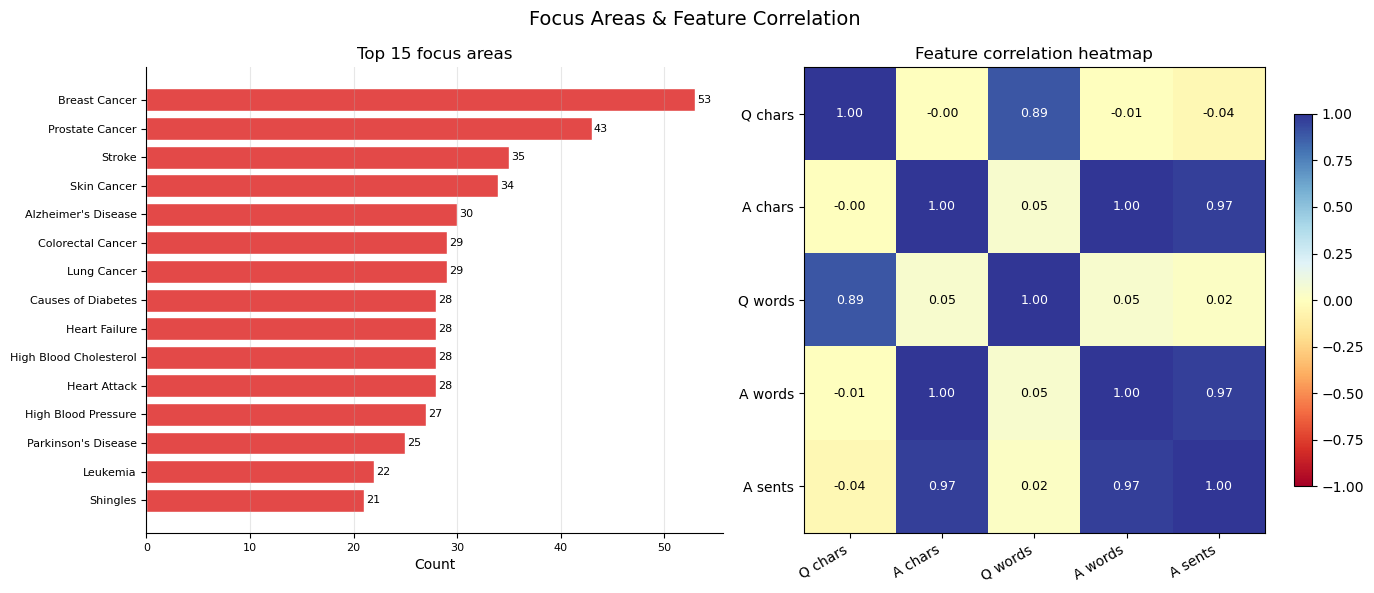

Saved: step9_focus_correlation.png


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Focus Areas & Feature Correlation', fontsize=14)

axes[0].barh(top_focus.index[::-1], top_focus.values[::-1], color='#e34948', edgecolor='white')
for i, v in enumerate(top_focus.values[::-1]):
    axes[0].text(v + 0.2, i, str(v), va='center', fontsize=8)
axes[0].set_title('Top 15 focus areas'); axes[0].set_xlabel('Count')
axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(axis='x', alpha=0.3); axes[0].tick_params(labelsize=8)

short_labels = ['Q chars','A chars','Q words','A words','A sents']
im = axes[1].imshow(corr.values, cmap='RdYlBu', vmin=-1, vmax=1, aspect='auto')
axes[1].set_xticks(range(len(short_labels))); axes[1].set_xticklabels(short_labels, rotation=30, ha='right')
axes[1].set_yticks(range(len(short_labels))); axes[1].set_yticklabels(short_labels)
for i in range(len(features)):
    for j in range(len(features)):
        val = corr.values[i, j]
        axes[1].text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(val) > 0.5 else 'black')
plt.colorbar(im, ax=axes[1], shrink=0.8)
axes[1].set_title('Feature correlation heatmap')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step9_focus_correlation.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: step9_focus_correlation.png")

In [ ]:
# STEP 10 — N-gram Analysis (bigrams & trigrams)

In [ ]:
#Single-word frequency (Step 3) misses meaning that comes from word combinations. "Clinical trial", "blood pressure", "side effect" only make sense as phrases — individual words give you "blood" and "pressure" separately, which is meaningless. Bigrams and trigrams surface these meaningful multi-word medical concepts that define the domain.

In [73]:
def get_ngrams(token_list: list[list[str]], n: int, top_k: int = 15) -> list[tuple]:
    """Extract top n-grams from a list of token lists."""
    ngrams = []
    for tokens in token_list:
        for i in range(len(tokens) - n + 1):
            ngrams.append(' '.join(tokens[i:i+n]))
    return Counter(ngrams).most_common(top_k)

q_bigrams   = get_ngrams(df['q_tokens'], 2)
a_bigrams   = get_ngrams(df['a_tokens'].head(2000), 2)
a_trigrams  = get_ngrams(df['a_tokens'].head(2000), 3)

print("\n── Top question bigrams ──")
for ng, c in q_bigrams[:8]: print(f"  {ng:<35} {c:>6,}")

print("\n── Top answer bigrams ──")
for ng, c in a_bigrams[:8]: print(f"  {ng:<35} {c:>6,}")


── Top question bigrams ──
  many people                          1,117
  people affected                      1,117
  genetic change                       1,087
  change related                       1,087
  syndrome inherited                     428
  clinical trial                         395
  research clinical                      394
  trial done                             394

── Top answer bigrams ──
  clinical trial                       4,963
  radiation therapy                    1,969
  cancer cell                          1,548
  cancer treatment                     1,203
  lymph node                           1,073
  cancer spread                        1,038
  part body                              950
  type treatment                         898


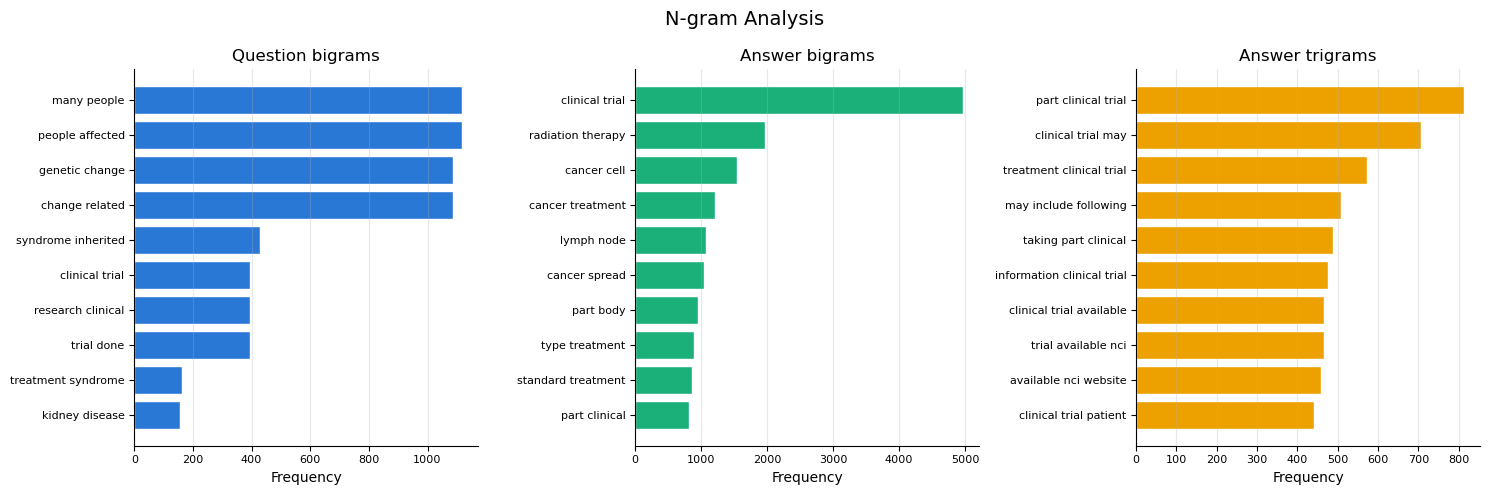

Saved: step10_ngrams.png


In [74]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('N-gram Analysis', fontsize=14)

for ax, (data, title, color) in zip(axes, [
    (q_bigrams,  'Question bigrams',  '#2a78d6'),
    (a_bigrams,  'Answer bigrams',    '#1baf7a'),
    (a_trigrams, 'Answer trigrams',   '#eda100'),
]):
    words = [d[0] for d in data[:10]]
    counts = [d[1] for d in data[:10]]
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(title); ax.set_xlabel('Frequency')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3); ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step10_ngrams.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: step10_ngrams.png")